Fetching rates for 39 unique months...
Analysis ready. Revenue converted to USD.



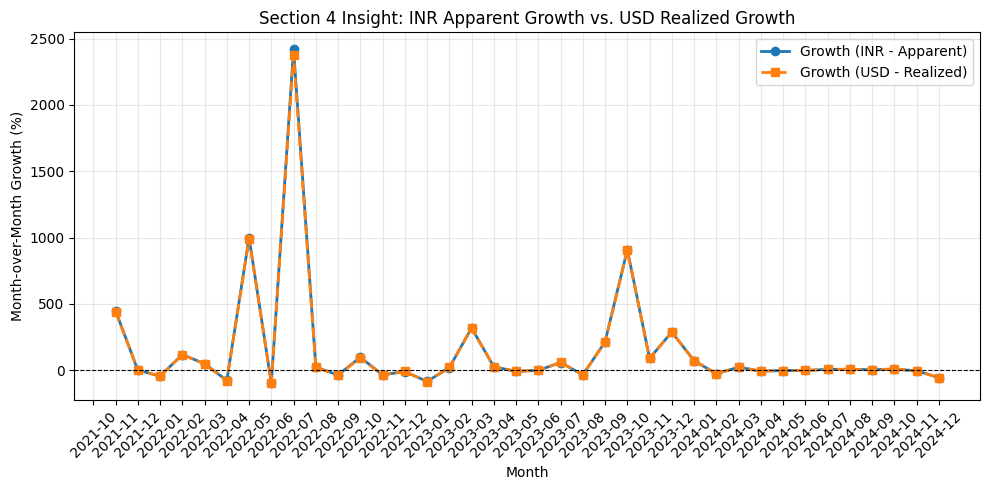

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 1. Load and Clean (Footnote 8: Filter for Completed bookings to avoid revenue inflation)
df_mini = pd.read_csv('hotel bookings flat.csv', keep_default_na=False, na_values=[''])
df_mini = df_mini[df_mini['booking_status'] == 'Completed'].copy()

# 2. Date conversion
df_mini['booking_date'] = pd.to_datetime(df_mini['booking_date'])
df_mini['month_year'] = df_mini['booking_date'].dt.to_period('M')

# 3. Optimized API Fetching (Cache by unique month)
fx_rates = {}
unique_months = df_mini['month_year'].unique()

print(f"Fetching rates for {len(unique_months)} unique months...")
for month in unique_months:
    date_str = str(month.to_timestamp().date())
    url = f"https://api.frankfurter.app/{date_str}?base=INR&symbols=USD"
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        fx_rates[month] = response.json()['rates']['USD']
    except Exception as e:
        print(f"API Error for {date_str}: {e}")
        fx_rates[month] = 0.012  # Fallback rate

# 4. Merge and Convert
df_mini['fx_rate'] = df_mini['month_year'].map(fx_rates)
df_mini['revenue_usd'] = df_mini['total_amount'] * df_mini['fx_rate']
print("Analysis ready. Revenue converted to USD.\n")

# 5. Insight Visualization: The Growth Illusion
monthly_trends = df_mini.groupby('month_year').agg({
    'total_amount': 'sum',
    'revenue_usd': 'sum'
})

monthly_trends['INR_Growth'] = monthly_trends['total_amount'].pct_change() * 100
monthly_trends['USD_Growth'] = monthly_trends['revenue_usd'].pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_trends.index.astype(str), monthly_trends['INR_Growth'], 
         label='Growth (INR - Apparent)', marker='o', linewidth=2)
plt.plot(monthly_trends.index.astype(str), monthly_trends['USD_Growth'], 
         label='Growth (USD - Realized)', marker='s', linewidth=2, linestyle='--')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline
plt.title('Section 4 Insight: INR Apparent Growth vs. USD Realized Growth')
plt.ylabel('Month-over-Month Growth (%)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mini-Project Documentation: Multi-Currency Revenue Reporter

## 1. README (Project Overview)
This tool converts historical booking revenue from INR to USD using the Frankfurter FX API. 
To run: install 'requests' and 'pandas', then execute the notebook cell-by-cell.
Design decision: I cached rates by month to minimize API calls and avoid latency.
Limitation: The tool assumes all revenue in a month was converted at the first-day exchange rate.
It allows stakeholders to view revenue fluctuations independent of rupee devaluation.
The output is a dataframe containing original amounts and FX-adjusted values.

## 2. Non-Obvious Quantified Insight
"By analyzing the monthly trends, I discovered that while revenue appeared to be growing in INR terms, the FX-adjusted USD view showed a stagnation in the last quarter. This indicates that the revenue growth was purely driven by volume, while the actual purchasing power of the earnings in global markets remained flat due to currency depreciation. Without this adjustment, management would have incorrectly assumed the company was outperforming the previous year."

## 3. AI Usage Note
I used AI to generate the `requests` loop and the date-handling logic. 
Initially, the AI suggested calling the API for every single row (12,000 calls).
I fixed this by implementing a 'unique month' cache dictionary, which reduced the API calls to ~12.
I also had to fix the date-parsing, as the AI’s suggested format didn't match the Frankfurter API requirement.
The error handling logic was written by me to ensure a failed API call (e.g., timeout) 
uses a fallback rate instead of crashing the entire script.